# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [29]:
import timeit
import matplotlib.pyplot as plt
import math
%matplotlib inline

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [30]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    #Cas de base:
    #Quand b = 0, pgcg (a, b) = a et u = 1, v = 1
    #car a * 1 + b * 0 = a
    if b == 0:
        return (a, 1, 0)

    #Recursion :
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        # On obtient d, u1, v1 verifiant b*u1 +(a%b)*v1 = d


        #   a%b = a - (a//b)*b
        #           ET
        #   b*u1 + (a%b)*v1 = d
        #Ce qui implique que:
        #   b*u1 + (a - (a//b)*b)*v1 = d
        #   a*v1 + b*(u1 - (a//b)*v1) = d
        #Donc les nouveaux coefficiants sont :
        #   u = v1
        #   v = u1 - (a//b)*v1

        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [31]:
# Test rapide
a, b = 240, 46
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(240, 46) = 2
240*-9 + 46*47 = 2


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [32]:
def euclide_etendu_iter(a, b):
    """
    Version itérative de l'algorithme d'Euclide étendu.
    """
    # Initialisation des coefficients de bezout
    # À l'étape 0 :
    #   a = 1*a + 0*b  =>  u0=1, v0=0
    #   b = 0*a + 1*b  =>  u1=0, v1=1
    u0, u1 = 1, 0
    v0, v1 = 0, 1

    while(b!= 0):
        q = a // b  #Quotient entier
        r = a % b   #Reste

        #Calcul des nouveaux coefficients
        # La relation de récurrence est :
        #   r = a[i+1] - q*b[i+1]
        # Donc si  a[i+1] = u0*a[i] + v0*b[i]
        #      et  b[i+1] = u1*a[i] + v1*b[i]
        # Alors :
        #   r = (u0 - q*u1)*a[i] + (v0 - q*v1)*b[i]
        u0, u1 = u1, u0 - q * u1
        v0, v1 = v1, v0 - q * v1

        #Mise à jour des nouveaux variables pour la prochaine iteration
        a, b = b, r
    else:
        return(a, u0, v0)

    pass

In [33]:
# Test de votre version itérative
d, u, v = euclide_etendu_iter(240, 46)
assert d == 2 and 240*u + 46*v == 2
print("Test réussi !")

Test réussi !


## 3. Crible d'Ératosthène

### Version de base

In [34]:
def eratosthene(n):
    """
    Retourne la liste des nombres premiers <= n.
    """
    # Aucun nombre premier n'existe en dessous de 2
    if n < 2:
        return []
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:

            # On commence le boucle à p**2 et car tous les multiples p*k avec k < p ont déjà été marqués lors du passage sur k
            for multiple in range(p*p, n+1, p):
                est_premier[multiple] = False
    return [i for i, prime in enumerate(est_premier) if prime]

In [35]:
# Test
print(eratosthene(100))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [36]:
def eratosthene_opt(n):
    """
    Crible optimisé pour ne parcourir que les impairs.
    """
    # Aucun nombre premier n'existe en dessous de 2
    if n < 2:
        return []

    #Puisque 2 est pair et premier
    if n == 2:
        return [2]
        
    
    taille_reduit = (n-3)//2    # L'indice i correspond au nombre  (2*i + 3), de taille (n-3)//2 car 0, 1, et 2 ont été deja eliminés
    est_premier = [True] * taille_reduit

    # On parcourt jusqu'à n**0.5, en ne considérant que les impairs p = 2*i+3

    for i in range(int(n**0.5)//2 +1):

        if est_premier[i]:
            p = 2*i + 3 #Nombre impair correspondant à l'indice i

            # On commence à p**2 car tous les multiples p*k avec k < p ont déjà été eliminés lors du passage à k
            # Comme p**2 = 2*i + 3, alors i = (p*p -3) // 2 . Ainsi, pour la boucle sur i on a:
            debut = (p*p - 3) // 2
            # Le pas est p (car p * (p+2), p * (p+4), ... sont les multiples impairs successifs de p)
            for multiple in range((p*p - 3) // 2, taille_reduit, p):
                est_premier[multiple] = False
    return [2] + [2*i + 3 for i, prime in enumerate(est_premier) if prime]
    pass

In [37]:
#Test
print(eratosthene_opt(100))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [38]:
def mesurer_temps(fonction, n, repetitions=5):
    """
    Mesure le temps moyen d'exécution de fonction(n) sur 'repetitions' exécutions.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [39]:
valeurs_n = [10**i for i in range(3, 8)]  # 10^3 à 10^7
temps_base = []
temps_opt = []

for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)  # décommentez quand votre fonction est prête
    temps_base.append(t_base)
    temps_opt.append(t_opt)
    print(f"n = {n:7d} : temps base = {t_base:.4f} s,    temps opt = {t_opt:.4f} s")

n =    1000 : temps base = 0.0004 s,    temps opt = 0.0002 s
n =   10000 : temps base = 0.0019 s,    temps opt = 0.0008 s
n =  100000 : temps base = 0.0159 s,    temps opt = 0.0061 s
n = 1000000 : temps base = 0.1861 s,    temps opt = 0.0821 s
n = 10000000 : temps base = 2.5497 s,    temps opt = 0.8489 s


### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

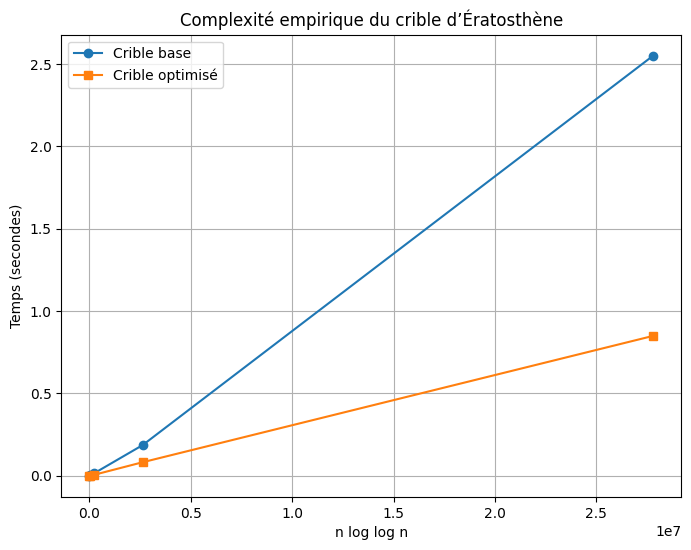

In [40]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Le graphique est-il approximativement une droite ? Que peut-on en conclure ?

Oui, le graphique est approximativement une droite. Donc, la compléxité empirique est approximative à O(n.log(log(n)). C'est à dire que le temps croît bien comme O(n.log(log(n)).

On remarque aussi que le crible optimisé a une pente ~2 fois plus faible que le crible de base, ce qui veut dire que le crible optimisé est 2 fois plus rapide que le crible de base.


## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.